In [8]:
# Author: Arthur Prigent
# Email: arthur.prigent@univ-brest.fr

In [9]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import datetime as dt
import gsw
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import ArcTools as Atools
import pandas as pd
import os
from datetime import date

# Vertical grid from ISAS

In [10]:
# read
dir_clim = '/data0/user/aprigent/ISAS/ISAS17_Mask.nc'
mask = xr.open_dataset(dir_clim)
zi = mask.depthCFD.data


# Vertical interpolation function

In [11]:
def interp_prof(x_old, y_old, x_new):

    # Import interpolation methods from SciPy
    # (only Akima1DInterpolator is actually used below)
    from scipy.interpolate import Akima1DInterpolator
    
    yi = []   # list to store interpolated profiles
    iyi = []  # list to store indices of successfully interpolated profiles
    
    # Loop over each profile (rows of y_old)
    for i in range(0, y_old.shape[0]):
        
        # Extract the i-th profile
        y = y_old[i, :]
        x = x_old[i, :]
        
        # Identify non-NaN values in y and x_old
        inans_y = ~np.isnan(y)
        inans_x = ~np.isnan(x)
       
        # print(len(inans_x),len(inans_y))
        # Keep only points where both x and y are valid
        inans = inans_y * inans_x
        
        
        # Proceed only if there are any valid points
        if np.any(inans):
            
            # Need at least 2 valid points for interpolation
            if len(y[inans]) > 1:
                # print(i)

                # Create Akima spline interpolator using valid data points
                try :
                    spl = Akima1DInterpolator(x[inans], y[inans])
                
                
                    # Interpolate profile onto the new x grid
                    prof = spl(x_new)
                
                    # Store interpolated profile and its original index
                    yi.append(prof)
                    iyi.append(i)
                except ValueError:
                    continue
                
    # Return:
    # - array of interpolated profiles
    # - array of indices of profiles that were successfully interpolated
    return np.array(yi), np.array(iyi)


### List ARGO profiles

In [106]:
argo_path = '/data0/user/aprigent/ARGO/Arctic/'
list_file = glob.glob(argo_path + '*_prof.nc')
# list_file = ['/data0/user/aprigent/ARGO/Arctic/6903119_prof.nc']
list_wmo = [os.path.basename(i).split('_')[0] for i in list_file]
# list_wmo = list_wmo[:5]
# list_wmo
list_wmo

['6900333',
 '6900305',
 '7900549',
 '6903565',
 '3902114',
 '5903387',
 '6900881',
 '6900883',
 '3902463',
 '7901120',
 '4900501',
 '5904774',
 '6901232',
 '6902727',
 '3901590',
 '3901851',
 '4901403',
 '6900240',
 '6900428',
 '6902549',
 '4903672',
 '6902912',
 '6901023',
 '3901623',
 '6904185',
 '7900536',
 '6900641',
 '4902437',
 '6990591',
 '4903774',
 '6900499',
 '7900178',
 '6990531',
 '2904026',
 '4901449',
 '4902532',
 '6900549',
 '6900638',
 '4903903',
 '6902016',
 '5907198',
 '6903582',
 '3902107',
 '6903102',
 '6902628',
 '4902557',
 '3901872',
 '69073',
 '6900648',
 '6902953',
 '6900195',
 '6902801',
 '6900615',
 '3902686',
 '6902545',
 '6901131',
 '6900668',
 '6903571',
 '6900193',
 '5904176',
 '6904240',
 '2900941',
 '6902670',
 '6900306',
 '4902530',
 '6903580',
 '6900796',
 '6901231',
 '1902603',
 '6903592',
 '7901124',
 '6902869',
 '4902428',
 '6900307',
 '6904086',
 '6902667',
 '6900220',
 '6902616',
 '6903574',
 '6900567',
 '6900198',
 '7900177',
 '6901170',
 '3901

In [107]:
def plot_trajectories(lon1,lat1,lon2,lat2):
    f,ax = plt.subplots(1,1,figsize=[10,10],subplot_kw={'projection': ccrs.NorthPolarStereo()})

    ftz=15

    Atools.plot_arctic_ax_map_new(ax)

    ax.scatter(lon1,
               lat1,
               marker='.',transform=ccrs.PlateCarree(),s=2,color='green',label='All',alpha=1)
    ax.scatter(lon2,
               lat2,
               marker='.',transform=ccrs.PlateCarree(),s=2,color='red',label='All',alpha=1)
    plt.show()
    

# Start looping on ARGO individual files

In [108]:
from datetime import date

# Output directory for QC-processed Argo data
data_out = '/data0/user/aprigent/texas/ARGO/bottom_interp_speed/'

# Counters and lists for tracking processing statistics
n_qc8 = []                        # Number of interpolated positions (QC flag = 8) per float
n_prof = []                       # Total number of profiles per float
interpolated_position_file = []   # List of floats that have interpolated positions
nb_temp_prof_init = 0             # Total temperature profiles before QC filtering
nb_psal_prof_init = 0             # Total salinity profiles before QC filtering
nb_temp_prof_qc_interp = 0        # Temperature profiles remaining after QC + interpolation
nb_psal_prof_qc_interp = 0        # Salinity profiles remaining after QC + interpolation
no_rtraj_wmo = []
no_cycle_index = []
no_actual_index = []
# Reference time for converting Julian days to Python ordinal dates
ref_time = dt.datetime(1950, 1, 1).toordinal()
black_list_wmo = ['4900501','6900648','6900195']
pos_bathy_follow_wmo = ['6903119', '6903143','6903144','6903145','6903146',
                                  '6903147','7901038','3902112','3902118','4903655',
                                  '6903587','6903588','6903589','6904087','7900549','7902188']
# ============================================================
# MAIN LOOP: iterate over each float WMO number
# ============================================================
for f in list_wmo:
    print('---------')
    print('    ')
    print(f)
    if f in black_list_wmo:
        print('skipping:',f)
        continue
    if f in pos_bathy_follow_wmo:
        print(f,' will be treated later...')
        continue

    # Load the profile NetCDF file for this float
    itp = xr.open_dataset('/data0/user/aprigent/ARGO/Arctic/' + f + '_prof.nc', decode_times=False)

    # Keep only ascending profiles (DIRECTION == 'A')
    mask_asc = itp.DIRECTION == b'A'
    itp = itp.isel(N_PROF=mask_asc)

    print(itp.CYCLE_NUMBER.values.shape)

    # Extract WMO ID
    platform_num = int(itp.PLATFORM_NUMBER[0].values)
    itp["LONGITUDE_traj"] = xr.full_like(itp["LONGITUDE"], np.nan)
    itp["LATITUDE_traj"]  = xr.full_like(itp["LONGITUDE"], np.nan)
    itp["SPEED"]          = xr.full_like(itp["LONGITUDE"], np.nan)
    itp["SPEED_EST"]      = xr.full_like(itp["LONGITUDE"], np.nan)

    # --------------------------------------------------------
    # Load trajectory file (robust cycle + fill grounded/park)
    # --------------------------------------------------------
    try:
        itp2 = xr.open_dataset(
            '/data0/user/aprigent/ARGO/Arctic/' + f + '_Rtraj.nc',
            decode_times=False
        )

        nprof = len(itp.CYCLE_NUMBER)

        # default outputs
        grounded_out = np.full(nprof, b'U', dtype='S1')
        park_out     = np.full(nprof, np.nan)

        # --------------------------------------------------------
        # CHECK IF ANY CYCLE INFO EXISTS
        # --------------------------------------------------------
        has_index  = "CYCLE_NUMBER_INDEX" in itp2.variables
        has_actual = "CYCLE_NUMBER_ACTUAL" in itp2.variables

        if not (has_index or has_actual):
            print("No cycle variable in trajectory:", f)
            # keep defaults and skip trajectory processing
        else:

            cyc_traj = (
                itp2.CYCLE_NUMBER_INDEX.values if has_index
                else itp2.CYCLE_NUMBER_ACTUAL.values
            )

            ground_traj = itp2.GROUNDED.values

            if "REPRESENTATIVE_PARK_PRESSURE" in itp2.variables:
                park_traj = itp2.REPRESENTATIVE_PARK_PRESSURE.values
            else:
                park_traj = np.full_like(ground_traj, np.nan)

            # build mapping (first occurrence wins)
            traj_map = {}
            for i, c in enumerate(cyc_traj):
                if c not in traj_map:
                    traj_map[c] = i

            # align to profile cycles
            for i, c in enumerate(itp.CYCLE_NUMBER.values):
                if c in traj_map:
                    j = traj_map[c]
                    grounded_out[i] = ground_traj[j]
                    park_out[i]     = park_traj[j]


    except FileNotFoundError:

        nprof = len(itp.CYCLE_NUMBER)

        grounded_out = np.full(nprof, b'U', dtype='S1')
        park_out     = np.full(nprof, np.nan)

    # --------------------------------------------------------
    # TIME QC CHECK
    # Keep only profiles with good time QC flag (JULD_QC == '1')
    # --------------------------------------------------------
    juld_qc = itp.JULD_QC.data
    qc_time = juld_qc == b'1'

    # Convert Julian days (since 1950-01-01) to Python ordinal dates
    juld_ord = np.array([int(ref_time + t) for t in itp.JULD.data[qc_time]])

    # Convert ordinal dates to YYYYMMDD float format for output
    d_tmp = [date.fromordinal(t) for t in juld_ord]
    yyyymmdd = [float(i.strftime('%Y%m%d')) for i in d_tmp]

    # Skip float if no profiles passed time QC
    if len(juld_ord) == 0:
        print('No QC time')
        continue

    # Skip float if all profiles predate year 2000 (data quality threshold)
    if juld_ord[-1] > dt.datetime(1999, 12, 31).toordinal():
        print('Time check passed for:', f)

        # --------------------------------------------------------
        # Extract core variables for profiles that passed time QC
        # --------------------------------------------------------
        pres     = itp.PRES.data[qc_time]
        lat      = itp.LATITUDE.data[qc_time]
        lon      = itp.LONGITUDE.data[qc_time]
        psal     = itp.PSAL.data[qc_time]
        temp     = itp.TEMP.data[qc_time]
        lat_new      = itp.LATITUDE_traj.data[qc_time]
        lon_new      = itp.LONGITUDE_traj.data[qc_time]
        speed_new = itp.SPEED.data[qc_time]
        speed_est = itp.SPEED_EST.data[qc_time]

        # Count profiles before any QC filtering
        nb_temp_prof_init += temp.shape[0]
        nb_psal_prof_init += psal.shape[0]

        # QC flag arrays for each variable
        psal_qc   = itp.PSAL_QC.data[qc_time]
        temp_qc   = itp.TEMP_QC.data[qc_time]
        data_mode = itp.DATA_MODE.data[qc_time]
        press_qc  = itp.PRES_QC.data[qc_time]
        pos_qc    = itp.POSITION_QC.data[qc_time]

        # Grounding flag and park pressure for these profiles
        ground = grounded_out[qc_time]
        park   = park_out[qc_time]

        # Build fixed-length (30-char) platform ID array for storage
        platform_id = np.array([int(p.decode().strip()) for p in itp.PLATFORM_NUMBER.values])
        platform_number_fixed = np.array(
        [
        ("ARGO" + x.decode("ascii").strip()).ljust(30).encode("ascii")
        for x in itp.PLATFORM_NUMBER.values
        ],
        dtype="S30")
        platform_id = platform_number_fixed[qc_time]

        # --------------------------------------------------------
        # PRESSURE QC: set bad-pressure levels to NaN before
        # converting pressure to depth
        # --------------------------------------------------------
        qc_press = press_qc == b'1'
        pres[~qc_press] = np.nan

        # Convert pressure (dbar) to depth (m), accounting for latitude
        dep      = -gsw.z_from_p(pres.T, lat).T
        park_dep = -gsw.z_from_p(park.T, lat).T

        # --------------------------------------------------------
        # GROUNDING DEPTH: compute max depth reached when grounded
        # --------------------------------------------------------
        pres_da  = xr.DataArray(pres, dims=("N_PROF", "N_LEVELS"))
        ground_da = xr.DataArray(ground, dims=("N_PROF",))

        # Maximum pressure/depth only for profiles flagged as grounded ('Y')
        max_pres_grounded = pres_da.where(ground_da == b"Y").max(dim="N_LEVELS")
        max_dep_grounded  = -gsw.z_from_p(max_pres_grounded.T, lat).T

        # --------------------------------------------------------
        # POSITION QC: accept good (flag=1) and interpolated (flag=8) positions
        # --------------------------------------------------------
        qc1_pos = (pos_qc == b'1') | (pos_qc == b'8')

        # Log floats that have interpolated positions
        if (pos_qc == b'8').any():
            print('This file has interpolated position:', f)
            interpolated_position_file.append(f)
            n_qc8.append((pos_qc == b'8').sum())
            n_prof.append(itp.N_PROF.shape[0])

        # --------------------------------------------------------
        # VARIABLE QC FLAGS
        # --------------------------------------------------------
        qc1_psal = psal_qc == b'1'     # Good salinity flag
        qc1_temp = temp_qc == b'1'     # Good temperature flag

        # Accept all data modes: Delayed (D), Adjusted (A), Real-time (R)
        qc_mode = (data_mode == b'D') | (data_mode == b'A') | (data_mode == b'R')

        # Broadcast 1D QC arrays to 2D (N_PROF x N_LEVELS) for masking
        qc_mode_2d_psal = np.broadcast_to(qc_mode[:, None], psal.shape)
        qc_mode_2d_temp = np.broadcast_to(qc_mode[:, None], temp.shape)
        qc_pos_2d_psal  = np.broadcast_to(qc1_pos[:, None], psal.shape)
        qc_pos_2d_temp  = np.broadcast_to(qc1_pos[:, None], temp.shape)

        # Combined mask: a data point is valid only if position, variable QC,
        # pressure QC, and data mode all pass simultaneously
        final_mask_temp = ~(qc_pos_2d_temp & qc1_temp & qc_press & qc_mode_2d_temp)
        final_mask_psal = ~(qc_pos_2d_psal & qc1_psal & qc_press & qc_mode_2d_psal)

        # Mask out bad data points
        psal[final_mask_psal] = np.nan
        temp[final_mask_temp] = np.nan

        # Track level counts (before interpolation)
        n_levels_temp = np.ones((dep.shape[0])) * dep.shape[1]
        n_levels_psal = np.ones((dep.shape[0])) * dep.shape[1]

        # --------------------------------------------------------
        # INTERPOLATION onto standard ISAS vertical grid (zi)
        # Returns interpolated array and indices of valid profiles
        # --------------------------------------------------------
        PSAL, ipsal = interp_prof(dep, psal, zi)
        TEMP, itemp = interp_prof(dep, temp, zi)

        # Apply physical range checks after interpolation
        TEMP[TEMP < -2]  = np.nan   # Below freezing point of seawater
        TEMP[TEMP > 30]  = np.nan   # Unrealistically warm
        PSAL[PSAL < 0]   = np.nan   # Negative salinity unphysical
        PSAL[PSAL > 40]  = np.nan   # Above realistic ocean salinity

        # --------------------------------------------------------
        # COLLECT METADATA for valid temperature profiles
        # --------------------------------------------------------
        if len(itemp) != 0:
            print('TEMP mean = ', np.nanmean(TEMP))
            print('TEMP min  = ', np.nanmin(TEMP))

            # Subset metadata to profiles that survived interpolation
            TIMEt        = np.array(juld_ord)[itemp]
            DATEt        = np.array(yyyymmdd)[itemp]
            LONt         = lon[itemp]
            LATt         = lat[itemp]
            LONt_new         = lon_new[itemp]
            LATt_new         = lat_new[itemp]
            SPEEDt_new         = speed_new[itemp]
            SPEEDt_est         = speed_est[itemp]
            GROUNDEDt    = ground[itemp]
            PARKt        = park_dep[itemp]
            platform_TEMP = platform_id[itemp]
            prof_qct     = pos_qc[itemp]
            prof_gdept   = np.array(max_dep_grounded)[itemp]

        # Update global profile counters
        nb_temp_prof_qc_interp += TEMP.shape[0]
        nb_psal_prof_qc_interp += PSAL.shape[0]

        # --------------------------------------------------------
        # COLLECT METADATA for valid salinity profiles
        # --------------------------------------------------------
        if len(ipsal) != len(itemp):
            print('psal/temp dimension missmatch')  # Warn if counts diverge

        if len(ipsal) != 0:
            TIMEs        = np.array(juld_ord)[ipsal]
            LONs         = lon[ipsal]
            LATs         = lat[ipsal]
            LONs_new         = lon_new[ipsal]
            LATs_new         = lat_new[ipsal]
            SPEEDs_new         = speed_new[ipsal]
            SPEEDs_est         = speed_est[ipsal]
            platform_PSAL = platform_id[ipsal]
            GROUNDEDs    = ground[ipsal]
            PARKs        = park_dep[ipsal]
            prof_qcs     = pos_qc[ipsal]
            prof_gdeps   = np.array(max_dep_grounded)[ipsal]
            

            # --------------------------------------------------------
            # BUILD AND SAVE SALINITY NetCDF OUTPUT
            # --------------------------------------------------------
            ds_psal = xr.Dataset({
                'prof_lat':   (['iPROF'], LATs),
                'prof_lon':   (['iPROF'], LONs),
                'prof_lat_traj':   (['iPROF'], LATs_new),
                'prof_lon_traj':   (['iPROF'], LONs_new),
                'prof_speed':   (['iPROF'], SPEEDs_new),
                'prof_speed_traj':   (['iPROF'], SPEEDs_est),
                'prof_date':  (['iPROF'], TIMEs),
                'prof_S':     (['iPROF', 'iDEPTH'], PSAL),
                'prof_Serr':  (['iPROF', 'iDEPTH'], np.ones((PSAL.shape)) * 0.01),  # Constant instrumental error
                'prof_pos':   (['iPROF'], prof_qcs),
                'prof_grnd':  (['iPROF'], GROUNDEDs),
                'prof_pdep':  (['iPROF'], PARKs),
                'prof_gdep':  (['iPROF'], prof_gdeps),
                'prof_descr': (['iPROF'], platform_PSAL),
                'prof_depth': (['iDEPTH'], zi)},
                coords={'iPROF': (['iPROF'], np.arange(0, len(TIMEs))),
                        'iDEPTH': (['iDEPTH'], zi)})

            # Global attributes
            ds_psal.attrs['Comments'] = 'Argo float salinity profiles (data mode=D) interpolated on ISAS vertical levels using a Akima 1D interpolator scheme (scipy)'
            ds_psal.attrs['Original file'] = f[33:]
            ds_psal.attrs['title']   = 'Argo salinity profiles on ISAS vertical grid'
            ds_psal.attrs['source']  = 'Argo'
            ds_psal.attrs['history'] = 'Created with xarray'

            # Variable attributes
            ds_psal['prof_lat'].attrs  = {'long_name': 'Latitude', 'units': 'degrees_north', 'standard_name': 'latitude'}
            ds_psal['prof_lon'].attrs  = {'long_name': 'Longitude', 'units': 'degrees_east', 'standard_name': 'longitude'}
            ds_psal['prof_lon_traj'].attrs = {
            'long_name':    'Estimated longitude from terrain-following algorithm',
            'units':        'degrees_east',
            'valid_min':    -180.0,
            'valid_max':    180.0,
            'description':  'Longitude of the float estimated by the terrain-following algorithm '
                            '(Yamazaki et al., 2019, doi:10.1029/2019JC015406). '
                            'For cycles with valid GPS fixes (POSITION_QC=1), this equals the '
                            'observed longitude. For cycles without valid fixes (POSITION_QC=8 or 9), '
                            'the position is estimated by finding a path consistent with the float '
                            'parking depth and GEBCO bathymetry, searching forward and backward '
                            'from the nearest known fixes and merging the two results. '
                            'NaN where the algorithm did not converge. '
                            'See lat_traj for the corresponding latitude, and longitude for the '
                            'initial interpolated positions used as a first guess. '
                            'Source code: https://github.com/cabanesc/Coriolis-under-ice-positioning/'
                            'blob/develop/estimate_profile_locations.m',
            'ancillary_variables': 'lat_traj speed_est depth_constraint position_qc',
            'references':   'Yamazaki et al. (2019), doi:10.1029/2019JC015406; '
                            'https://github.com/cabanesc/Coriolis-under-ice-positioning/'
                            'blob/develop/estimate_profile_locations.m',
        }
            ds_psal['prof_lat_traj'].attrs = {
            'long_name':    'Estimated latitude from terrain-following algorithm',
            'units':        'degrees_north',
            'valid_min':    -90.0,
            'valid_max':    90.0,
            'description':  'Latitude of the float estimated by the terrain-following algorithm '
                            '(Yamazaki et al., 2019, doi:10.1029/2019JC015406). '
                            'For cycles with valid GPS fixes (POSITION_QC=1), this equals the '
                            'observed latitude. For cycles without valid fixes (POSITION_QC=8 or 9), '
                            'the position is estimated by finding a path consistent with the float '
                            'parking depth and GEBCO bathymetry, searching forward and backward '
                            'from the nearest known fixes and merging the two results. '
                            'NaN where the algorithm did not converge. '
                            'See lon_traj for the corresponding longitude, and latitude for the '
                            'initial interpolated positions used as a first guess. '
                            'Source code: https://github.com/cabanesc/Coriolis-under-ice-positioning/'
                            'blob/develop/estimate_profile_locations.m',
            'ancillary_variables': 'lon_traj speed_est depth_constraint position_qc',
            'references':   'Yamazaki et al. (2019), doi:10.1029/2019JC015406; '
                            'https://github.com/cabanesc/Coriolis-under-ice-positioning/'
                            'blob/develop/estimate_profile_locations.m',
        }
            ds_psal['prof_speed'].attrs = {
                'long_name':    'Float drift speed from initial interpolated trajectory',
                'units':        'cm s-1',
                'description':  'Horizontal drift speed computed from consecutive positions along the '
                                'initial interpolated trajectory (before terrain-following optimization). '
                                'Computed as: speed = 100 * geodesic_distance(pos[i-1], pos[i]) / '
                                '(JULD_LOCATION[i] - JULD_LOCATION[i-1]) / 86400, where geodesic_distance '
                                'is in meters and time difference is converted from days to seconds. '
                                'For cycles with valid GPS fixes (POSITION_QC=1), positions are observed; '
                                'elsewhere they are linearly or geodesically interpolated between known fixes.',
                'valid_min':    0.0,
                'valid_max':    200.0,
            }

            ds_psal['prof_speed_traj'].attrs = {
                'long_name':    'Float drift speed from terrain-following estimated trajectory',
                'units':        'cm s-1',
                'description':  'Horizontal drift speed computed from consecutive positions along the '
                                'final terrain-following estimated trajectory. '
                                'Computed as: speed_est = 100 * geodesic_distance(traj[i-1], traj[i]) / '
                                '(JULD[i] - JULD[i-1]) / 86400, where geodesic_distance is in meters '
                                'and time difference is converted from days to seconds using JULD '
                                '(profile date) rather than JULD_LOCATION. '
                                'NaN where the terrain-following algorithm did not converge.',
                'valid_min':    0.0,
                'valid_max':    200.0,
            }
            ds_psal['prof_date'].attrs = {'long_name': 'Time', "units": "days since 0001-01-01 (Python datetime system)"}
            ds_psal['prof_S'].attrs    = {'long_name': 'Salinity (S78 - PSS)', 'units': '1e-3',
                                     'standard_name': 'sea_water_practical_salinity'}
            ds_psal['prof_Serr'].attrs = {'long_name': 'Instrumental error'}
            ds_psal['prof_depth'].attrs = {'long_name': 'Depth', 'units': 'm', 'positive': 'down', 'standard_name': 'depth'}
            ds_psal['prof_pdep'].attrs  = {'long_name': 'Depth of at which the float parked', 'units': 'm'}
            ds_psal['prof_gdep'].attrs  = {'long_name': 'Depth of when the float grounded', 'units': 'm',
                                      'description': "Indicates the max depth of the profile and prof_grnd=='Y'"}
            ds_psal['prof_grnd'].attrs  = {
                'long_name':   'Profiling float ground/bathymetry contact flag',
                'units':       '1',
                'flag_values': 'Y, B, N, S, U',
                'flag_meanings': 'ground_contact bathymetry_verified no_contact shallow_drift unknown',
                'description': 'Indicates whether a profiling float touched the seafloor or was constrained by bathymetry or depth limitations'
            }
            ds_psal.to_netcdf(data_out + f + '_ASTE_PSAL.nc')  # Save salinity file (currently disabled)

            # --------------------------------------------------------
            # BUILD AND SAVE TEMPERATURE NetCDF OUTPUT
            # --------------------------------------------------------
            ds_temp = xr.Dataset({
                'prof_lat':   (['iPROF'], LATt),
                'prof_lon':   (['iPROF'], LONt),
                'prof_lat_traj':   (['iPROF'], LATt_new),
                'prof_lon_traj':   (['iPROF'], LONt_new),
                'prof_speed':   (['iPROF'], SPEEDt_new),
                'prof_speed_traj':   (['iPROF'], SPEEDt_est),
                'prof_date':  (['iPROF'], TIMEt),
                'prof_T':     (['iPROF', 'iDEPTH'], TEMP),
                'prof_Terr':  (['iPROF', 'iDEPTH'], np.ones((TEMP.shape)) * 0.05),  # Constant instrumental error
                'prof_pos':   (['iPROF'], prof_qct),
                'prof_grnd':  (['iPROF'], GROUNDEDt),
                'prof_gdep':  (['iPROF'], prof_gdept),
                'prof_pdep':  (['iPROF'], PARKt),
                'prof_descr': (['iPROF'], platform_TEMP),
                'prof_depth': (['iDEPTH'], zi)},
                coords={'iPROF': (['iPROF'], np.arange(0, len(TIMEt))),
                        'iDEPTH': (['iDEPTH'], zi)})

            # Global attributes
            ds_temp.attrs['Comments'] = 'Argo float temperature profiles (data mode=D) interpolated on ISAS vertical using a Akima 1D interpolator scheme (scipy)'
            ds_temp.attrs['Original file'] = f[33:]
            ds_temp.attrs['title']   = 'Argo temperature profiles on ISAS vertical grid'
            ds_temp.attrs['source']  = 'Argo'
            ds_temp.attrs['history'] = 'Created with xarray'

            # Variable attributes
            ds_temp['prof_lat'].attrs  = {'long_name': 'Latitude', 'units': 'degrees_north', 'standard_name': 'latitude'}
            ds_temp['prof_lon'].attrs  = {'long_name': 'Longitude', 'units': 'degrees_east', 'standard_name': 'longitude'}
            ds_temp['prof_lon_traj'].attrs = {
            'long_name':    'Estimated longitude from terrain-following algorithm',
            'units':        'degrees_east',
            'valid_min':    -180.0,
            'valid_max':    180.0,
            'description':  'Longitude of the float estimated by the terrain-following algorithm '
                            '(Yamazaki et al., 2019, doi:10.1029/2019JC015406). '
                            'For cycles with valid GPS fixes (POSITION_QC=1), this equals the '
                            'observed longitude. For cycles without valid fixes (POSITION_QC=8 or 9), '
                            'the position is estimated by finding a path consistent with the float '
                            'parking depth and GEBCO bathymetry, searching forward and backward '
                            'from the nearest known fixes and merging the two results. '
                            'NaN where the algorithm did not converge. '
                            'See lat_traj for the corresponding latitude, and longitude for the '
                            'initial interpolated positions used as a first guess. '
                            'Source code: https://github.com/cabanesc/Coriolis-under-ice-positioning/'
                            'blob/develop/estimate_profile_locations.m',
            'ancillary_variables': 'lat_traj speed_est depth_constraint position_qc',
            'references':   'Yamazaki et al. (2019), doi:10.1029/2019JC015406; '
                            'https://github.com/cabanesc/Coriolis-under-ice-positioning/'
                            'blob/develop/estimate_profile_locations.m',
        }
            ds_temp['prof_lat_traj'].attrs = {
            'long_name':    'Estimated latitude from terrain-following algorithm',
            'units':        'degrees_north',
            'valid_min':    -90.0,
            'valid_max':    90.0,
            'description':  'Latitude of the float estimated by the terrain-following algorithm '
                            '(Yamazaki et al., 2019, doi:10.1029/2019JC015406). '
                            'For cycles with valid GPS fixes (POSITION_QC=1), this equals the '
                            'observed latitude. For cycles without valid fixes (POSITION_QC=8 or 9), '
                            'the position is estimated by finding a path consistent with the float '
                            'parking depth and GEBCO bathymetry, searching forward and backward '
                            'from the nearest known fixes and merging the two results. '
                            'NaN where the algorithm did not converge. '
                            'See lon_traj for the corresponding longitude, and latitude for the '
                            'initial interpolated positions used as a first guess. '
                            'Source code: https://github.com/cabanesc/Coriolis-under-ice-positioning/'
                            'blob/develop/estimate_profile_locations.m',
            'ancillary_variables': 'lon_traj speed_est depth_constraint position_qc',
            'references':   'Yamazaki et al. (2019), doi:10.1029/2019JC015406; '
                            'https://github.com/cabanesc/Coriolis-under-ice-positioning/'
                            'blob/develop/estimate_profile_locations.m',
        }
            ds_temp['prof_speed'].attrs = {
                'long_name':    'Float drift speed from initial interpolated trajectory',
                'units':        'cm s-1',
                'description':  'Horizontal drift speed computed from consecutive positions along the '
                                'initial interpolated trajectory (before terrain-following optimization). '
                                'Computed as: speed = 100 * geodesic_distance(pos[i-1], pos[i]) / '
                                '(JULD_LOCATION[i] - JULD_LOCATION[i-1]) / 86400, where geodesic_distance '
                                'is in meters and time difference is converted from days to seconds. '
                                'For cycles with valid GPS fixes (POSITION_QC=1), positions are observed; '
                                'elsewhere they are linearly or geodesically interpolated between known fixes.',
                'valid_min':    0.0,
                'valid_max':    200.0,
            }

            ds_temp['prof_speed_traj'].attrs = {
                'long_name':    'Float drift speed from terrain-following estimated trajectory',
                'units':        'cm s-1',
                'description':  'Horizontal drift speed computed from consecutive positions along the '
                                'final terrain-following estimated trajectory. '
                                'Computed as: speed_est = 100 * geodesic_distance(traj[i-1], traj[i]) / '
                                '(JULD[i] - JULD[i-1]) / 86400, where geodesic_distance is in meters '
                                'and time difference is converted from days to seconds using JULD '
                                '(profile date) rather than JULD_LOCATION. '
                                'NaN where the terrain-following algorithm did not converge.',
                'valid_min':    0.0,
                'valid_max':    200.0,
            }
            ds_temp['prof_date'].attrs = {'long_name': 'Time', "units": "days since 0001-01-01 (Python datetime system)"}
            ds_temp['prof_T'].attrs    = {'long_name': 'Temperature (T90)', 'units': 'degree_Celsius',
                                     'standard_name': 'sea_water_temperature'}
            ds_temp['prof_Terr'].attrs = {'long_name': 'Instrumental error'}
            ds_temp['prof_depth'].attrs = {'long_name': 'Depth', 'units': 'm', 'positive': 'down', 'standard_name': 'depth'}
            ds_temp['prof_pdep'].attrs  = {'long_name': 'Depth of at which the float parked', 'units': 'm'}
            ds_temp['prof_gdep'].attrs  = {'long_name': 'Depth of when the float grounded', 'units': 'm',
                                      'description': "Indicates the max depth of the profile and prof_grnd=='Y'"}
            ds_temp['prof_grnd'].attrs  = {
                'long_name':   'Profiling float ground/bathymetry contact flag',
                'units':       '1',
                'flag_values': 'Y, B, N, S, U',
                'flag_meanings': 'ground_contact bathymetry_verified no_contact shallow_drift unknown',
                'description': 'Indicates whether a profiling float touched the seafloor or was constrained by bathymetry or depth limitations'
            }
            ds_temp.to_netcdf(data_out + f + '_ASTE_TEMP.nc')  # Save temperature file (currently disabled)
#             fig,ax = plt.subplots(1,2,figsize=[15,10])
#             ax=ax.ravel()


#             ax[0].pcolor(ds_psal.iPROF,ds_psal.iDEPTH,ds_psal.prof_S.T)
#             ax[0].plot(ds_psal.iPROF,ds_psal.prof_gdep,color='red')
#             ax[0].invert_yaxis()
#             ax[0].set_ylim([2000,0])

#             ax[1].pcolor(ds_temp.iPROF,ds_temp.iDEPTH,ds_temp.prof_T.T)
#             ax[1].plot(ds_temp.iPROF,ds_temp.prof_gdep,color='red')
#             ax[1].invert_yaxis()
#             ax[1].set_ylim([2000,0])
            # plt.savefig('/data0/user/aprigent/figure_argos/'+f+'.png')

---------
    
6900333
(147,)
Time check passed for: 6900333
TEMP mean =  7.074131181726802
TEMP min  =  -1.6982161422168305
psal/temp dimension missmatch
---------
    
6900305
(158,)
Time check passed for: 6900305
TEMP mean =  -0.34035840944783574
TEMP min  =  -1.0473279522882726
psal/temp dimension missmatch
---------
    
7900549
7900549  will be treated later...
---------
    
6903565
(603,)
Time check passed for: 6903565
This file has interpolated position: 6903565
TEMP mean =  2.11458323904832
TEMP min  =  -1.7498916556485102
psal/temp dimension missmatch
---------
    
3902114
(170,)
Time check passed for: 3902114
TEMP mean =  1.811774911650026
TEMP min  =  -0.7900070276100517
---------
    
5903387
(306,)
Time check passed for: 5903387
TEMP mean =  4.73825657191914
TEMP min  =  0.9252664623652633
---------
    
6900881
(23,)
Time check passed for: 6900881
This file has interpolated position: 6900881
TEMP mean =  2.678379845496004
TEMP min  =  -0.7739969210224854
---------
    

/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/scipy/interpolate/_cubic.py:445: RuntimeWarning: overflow encountered in multiply
  t[ind] = (f1[ind] * m[(x_ind + 1,) + y_ind] +
/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/scipy/interpolate/_cubic.py:446: RuntimeWarning: overflow encountered in multiply
  f2[ind] * m[(x_ind + 2,) + y_ind]) / f12[ind]


TEMP mean =  0.1908478437575007
TEMP min  =  -1.7822409810844224
---------
    
6902038
(104,)
Time check passed for: 6902038
TEMP mean =  0.6426471749162619
TEMP min  =  -0.9255996605128342
---------
    
6900344
(199,)
Time check passed for: 6900344
TEMP mean =  4.354535311833328
TEMP min  =  -0.8332504217026461
psal/temp dimension missmatch
---------
    
6903119
6903119  will be treated later...
---------
    
6900339
(58,)
Time check passed for: 6900339
TEMP mean =  -0.4377032726513481
TEMP min  =  -0.8090250326468058
---------
    
5907173
(36,)
Time check passed for: 5907173
This file has interpolated position: 5907173
TEMP mean =  1.1418971506024793
TEMP min  =  -1.840000033378601
---------
    
6901226
(68,)
Time check passed for: 6901226
TEMP mean =  2.0273068432229313
TEMP min  =  -0.7954302144575164
---------
    
6903562
(223,)
Time check passed for: 6903562
This file has interpolated position: 6903562
TEMP mean =  1.8929073919701256
TEMP min  =  -0.7861798813091866
psal/t

/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/scipy/interpolate/_cubic.py:445: RuntimeWarning: overflow encountered in multiply
  t[ind] = (f1[ind] * m[(x_ind + 1,) + y_ind] +
/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/scipy/interpolate/_cubic.py:446: RuntimeWarning: overflow encountered in multiply
  f2[ind] * m[(x_ind + 2,) + y_ind]) / f12[ind]


(285,)
Time check passed for: 6903547
This file has interpolated position: 6903547
TEMP mean =  0.8245095075245913
TEMP min  =  -1.8450000286102295
psal/temp dimension missmatch
---------
    
6900601
(73,)
Time check passed for: 6900601
TEMP mean =  1.661969718747648
TEMP min  =  -0.8394347458985
---------
    
2904019
(34,)
Time check passed for: 2904019
TEMP mean =  2.5815824584092986
TEMP min  =  -0.01688607841044404
---------
    
4903455
(1292,)
Time check passed for: 4903455
TEMP mean =  1.9111488623211386
TEMP min  =  -1.546885594297123
psal/temp dimension missmatch
---------
    
6900678
(123,)
Time check passed for: 6900678
TEMP mean =  6.555250915124631
TEMP min  =  -0.8393373893861078
---------
    
3902593
(5,)
Time check passed for: 3902593
TEMP mean =  0.05405919570008034
TEMP min  =  -1.438754529508664
---------
    
6903591
(189,)
Time check passed for: 6903591
TEMP mean =  1.0996361956968705
TEMP min  =  -0.7563369432490671
---------
    
3902464
(112,)
Time check pas

...

TEMP mean =  5.703501242212817
TEMP min  =  -1.8669999837875366
psal/temp dimension missmatch
---------
    
6900192
(89,)
No cycle variable in trajectory: 6900192
Time check passed for: 6900192
TEMP mean =  2.213948621574573
TEMP min  =  -0.9115046803566481
---------
    
6902543
(231,)
Time check passed for: 6902543
This file has interpolated position: 6902543
TEMP mean =  2.322638901320106
TEMP min  =  -0.8130000233650208
---------
    
1902759
(91,)
Time check passed for: 1902759
This file has interpolated position: 1902759
TEMP mean =  1.7918493643714353
TEMP min  =  -1.7757900795576047
---------
    
6900808
(44,)
Time check passed for: 6900808
TEMP mean =  1.3441752984821045
TEMP min  =  -0.8702702691751499
psal/temp dimension missmatch
---------
    
3902681
(492,)
Time check passed for: 3902681
TEMP mean =  8.31949660387745
TEMP min  =  2.545526384544215
psal/temp dimension missmatch
---------
    
4903040
(288,)
Time check passed for: 4903040
TEMP mean =  0.00301741350331311


/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/scipy/interpolate/_cubic.py:445: RuntimeWarning: overflow encountered in multiply
  t[ind] = (f1[ind] * m[(x_ind + 1,) + y_ind] +
/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/scipy/interpolate/_cubic.py:446: RuntimeWarning: overflow encountered in multiply
  f2[ind] * m[(x_ind + 2,) + y_ind]) / f12[ind]


(76,)
No cycle variable in trajectory: 6901135
Time check passed for: 6901135
TEMP mean =  6.251346527826019
TEMP min  =  2.447977656734735
---------
    
4903037
(460,)
Time check passed for: 4903037
TEMP mean =  -0.030894186550189405
TEMP min  =  -1.691259286869604
---------
    
6901077
(83,)
Time check passed for: 6901077
TEMP mean =  1.2050667372743444
TEMP min  =  -0.8061264441997018
---------
    
6900667
(245,)
Time check passed for: 6900667


/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/scipy/interpolate/_cubic.py:445: RuntimeWarning: overflow encountered in multiply
  t[ind] = (f1[ind] * m[(x_ind + 1,) + y_ind] +
/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/scipy/interpolate/_cubic.py:446: RuntimeWarning: overflow encountered in multiply
  f2[ind] * m[(x_ind + 2,) + y_ind]) / f12[ind]


TEMP mean =  1.6747153326920399
TEMP min  =  -0.7937958822573653
psal/temp dimension missmatch
---------
    
5904988
(296,)
Time check passed for: 5904988
This file has interpolated position: 5904988
TEMP mean =  4.897207183591854
TEMP min  =  -1.5094212380023802
---------
    
6900194
(74,)
No cycle variable in trajectory: 6900194
Time check passed for: 6900194
TEMP mean =  1.229950420605204
TEMP min  =  -0.8808875225890447
---------
    
4901809
(274,)
Time check passed for: 4901809
TEMP mean =  4.926308839431336
TEMP min  =  -1.0913939529029701
psal/temp dimension missmatch
---------
    
6900376
(127,)
Time check passed for: 6900376
TEMP mean =  5.218878721674163
TEMP min  =  -0.9020199307963073
---------
    
6901909
(217,)
Time check passed for: 6901909
This file has interpolated position: 6901909
TEMP mean =  2.4717076205193727
TEMP min  =  -0.7988091289721908
psal/temp dimension missmatch
---------
    
7900171
(31,)
Time check passed for: 7900171
TEMP mean =  -0.4184752844240

In [109]:



def plot_trajectories_new(ds):
    f,ax = plt.subplots(1,2,figsize=[10,10],subplot_kw={'projection': ccrs.NorthPolarStereo()})
    ax=ax.ravel()
    ftz=15

    Atools.plot_arctic_ax_map_new(ax[0])
    ax[0].scatter(ds_temp.prof_lon_traj,
                ds_temp.prof_lat_traj,color='grey',marker='.',transform=ccrs.PlateCarree(),s=2)

    ax[0].scatter(ds_temp.prof_lon_traj.where(ds_temp.prof_pos==b'1'),
                ds_temp.prof_lat_traj.where(ds_temp.prof_pos==b'1'),
                  color='green',marker='.',transform=ccrs.PlateCarree(),s=2)

    ax[0].scatter(ds_temp.prof_lon_traj.where(ds_temp.prof_grnd==b'Y'),
                ds_temp.prof_lat_traj.where(ds_temp.prof_grnd==b'Y'),
                  color='red',marker='.',transform=ccrs.PlateCarree(),s=2)
    
    
    Atools.plot_arctic_ax_map_new(ax[1])
    ax[1].scatter(ds_temp.prof_lon,
                ds_temp.prof_lat,color='grey',marker='.',transform=ccrs.PlateCarree(),s=2)

    ax[1].scatter(ds_temp.prof_lon.where(ds_temp.prof_pos==b'1'),
                ds_temp.prof_lat.where(ds_temp.prof_pos==b'1'),color='green',
                 marker='.',transform=ccrs.PlateCarree(),s=2)

    ax[1].scatter(ds_temp.prof_lon.where(ds_temp.prof_grnd==b'Y'),
                ds_temp.prof_lat.where(ds_temp.prof_grnd==b'Y'),color='red',
                 marker='.',transform=ccrs.PlateCarree(),s=2)

    plt.show()
    

# Start looping on Argo floats with trajectory corrected

---------
    
7901038
Correcting lon/lat


/tmp/ipykernel_3424833/1265097630.py:41: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv('/data0/user/aprigent/ARGO/estimate_profile_locations_' + str(f) + '.csv',


Time check passed for: 7901038
TEMP mean =  0.8045425973287398
TEMP min  =  -1.871000051498413


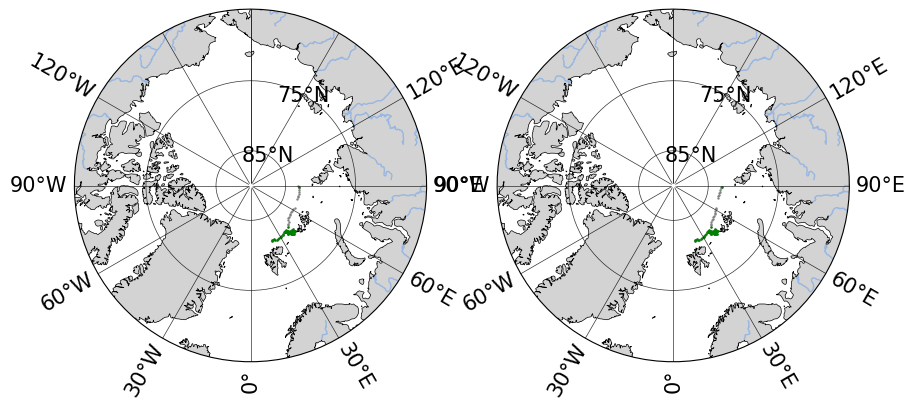

In [112]:
from datetime import date

# Output directory for QC-processed Argo data
data_out = '/data0/user/aprigent/texas/ARGO/bottom_interp_speed/'

# Counters and lists for tracking processing statistics
n_qc8 = []                        # Number of interpolated positions (QC flag = 8) per float
n_prof = []                       # Total number of profiles per float
interpolated_position_file = []   # List of floats that have interpolated positions
nb_temp_prof_init = 0             # Total temperature profiles before QC filtering
nb_psal_prof_init = 0             # Total salinity profiles before QC filtering
nb_temp_prof_qc_interp = 0        # Temperature profiles remaining after QC + interpolation
nb_psal_prof_qc_interp = 0        # Salinity profiles remaining after QC + interpolation
no_rtraj_wmo = []
no_cycle_index = []
no_actual_index = []
# Reference time for converting Julian days to Python ordinal dates
ref_time = dt.datetime(1950, 1, 1).toordinal()

pos_bathy_follow_wmo = ['6903119', '6903143','6903144','6903145','6903146',
                                  '6903147','7901038','3902112','3902118','4903655',
                                  '6903587','6903588','6903589','6904087','7900549','7902188']


pos_bathy_follow_wmo = ['7901038']
# ============================================================
# MAIN LOOP: iterate over each float WMO number
# ============================================================
for f in pos_bathy_follow_wmo:
    print('---------')
    print('    ')
    print(f)
    
    # Load the profile NetCDF file for this float
    itp = xr.open_dataset('/data0/user/aprigent/ARGO/Arctic/' + f + '_prof.nc', decode_times=False)

    # Keep only ascending profiles (DIRECTION == 'A')
    mask_asc = itp.DIRECTION == b'A'
    itp = itp.isel(N_PROF=mask_asc)
    print('Correcting lon/lat')
    df = pd.read_csv('/data0/user/aprigent/ARGO/estimate_profile_locations_' + str(f) + '.csv',
                     sep=";", index_col=False)
    ds_traj = xr.Dataset.from_dataframe(df)
    ds_traj = ds_traj.where(ds_traj.Dir==2,drop=True)
    # Replace Argo lon/lat with corrected trajectory values
    cycle = ds_traj.CyNum.values
    lon_corr = ds_traj.Lon.values
    lat_corr = ds_traj.Lat.values
    speed_corr = ds_traj.Speed.values
    lon_test = ds_traj.TrajLon.values
    lat_test = ds_traj.TrajLat.values
    speed_test = ds_traj.SpeedEst.values
    # Initialise new variables to NaN before the loop
    itp["LONGITUDE_traj"] = itp["LONGITUDE"].copy()
    itp["LATITUDE_traj"]  = itp["LATITUDE"].copy()
    itp["SPEED"]          = xr.full_like(itp["LONGITUDE"], np.nan)
    itp["SPEED_EST"]      = xr.full_like(itp["LONGITUDE"], np.nan)

    for c, lo, la, lotrj, latrj,sp,spest, pqc in zip(cycle, lon_corr, lat_corr,
                                                     lon_test, lat_test,speed_corr,
                                                     speed_test, ds_traj.PosQC.values):

        if np.isnan(lo) or np.isnan(la):
            print(f"Skipping cycle {c}: missing lon/lat")
            continue

        # only apply correction when PosQC == 8
        if pqc != 8:
            continue
        
        # print(itp["CYCLE_NUMBER"].values, c)

        mask = itp["CYCLE_NUMBER"] == c
        # print(mask)
        # update lon/lat
        itp["LONGITUDE"] = xr.where(mask, lo, itp["LONGITUDE"])
        itp["LATITUDE"] = xr.where(mask, la, itp["LATITUDE"])
        
        # update traj lon/lat 
        itp["LONGITUDE_traj"] = xr.where(mask, lotrj, itp["LONGITUDE_traj"])
        itp["LATITUDE_traj"]  = xr.where(mask, latrj, itp["LATITUDE_traj"])

        # update speed variables
        itp["SPEED"]     = xr.where(mask, sp,    itp["SPEED"])
        itp["SPEED_EST"] = xr.where(mask, spest, itp["SPEED_EST"])
        

        # flag QC as corrected
        itp["POSITION_QC"] = xr.where(mask, b"7", itp["POSITION_QC"])
    
    # Extract WMO ID
    platform_num = int(itp.PLATFORM_NUMBER[0].values)

    # --------------------------------------------------------
    # Load trajectory file (robust cycle + fill grounded/park)
    # --------------------------------------------------------
    try:
        itp2 = xr.open_dataset(
            '/data0/user/aprigent/ARGO/Arctic/' + f + '_Rtraj.nc',
            decode_times=False
        )

        nprof = len(itp.CYCLE_NUMBER)

        # default outputs
        grounded_out = np.full(nprof, b'U', dtype='S1')
        park_out     = np.full(nprof, np.nan)

        # --------------------------------------------------------
        # CHECK IF ANY CYCLE INFO EXISTS
        # --------------------------------------------------------
        has_index  = "CYCLE_NUMBER_INDEX" in itp2.variables
        has_actual = "CYCLE_NUMBER_ACTUAL" in itp2.variables

        if not (has_index or has_actual):
            print("No cycle variable in trajectory:", f)
            # keep defaults and skip trajectory processing
        else:

            cyc_traj = (
                itp2.CYCLE_NUMBER_INDEX.values if has_index
                else itp2.CYCLE_NUMBER_ACTUAL.values
            )

            ground_traj = itp2.GROUNDED.values

            if "REPRESENTATIVE_PARK_PRESSURE" in itp2.variables:
                park_traj = itp2.REPRESENTATIVE_PARK_PRESSURE.values
            else:
                park_traj = np.full_like(ground_traj, np.nan)

            # build mapping (first occurrence wins)
            traj_map = {}
            for i, c in enumerate(cyc_traj):
                if c not in traj_map:
                    traj_map[c] = i

            # align to profile cycles
            for i, c in enumerate(itp.CYCLE_NUMBER.values):
                if c in traj_map:
                    j = traj_map[c]
                    grounded_out[i] = ground_traj[j]
                    park_out[i]     = park_traj[j]


    except FileNotFoundError:

        nprof = len(itp.CYCLE_NUMBER)

        grounded_out = np.full(nprof, b'U', dtype='S1')
        park_out     = np.full(nprof, np.nan)

    # --------------------------------------------------------
    # TIME QC CHECK
    # Keep only profiles with good time QC flag (JULD_QC == '1')
    # --------------------------------------------------------
    juld_qc = itp.JULD_QC.data
    qc_time = juld_qc == b'1'

    # Convert Julian days (since 1950-01-01) to Python ordinal dates
    juld_ord = np.array([int(ref_time + t) for t in itp.JULD.data[qc_time]])

    # Convert ordinal dates to YYYYMMDD float format for output
    d_tmp = [date.fromordinal(t) for t in juld_ord]
    yyyymmdd = [float(i.strftime('%Y%m%d')) for i in d_tmp]

    # Skip float if no profiles passed time QC
    if len(juld_ord) == 0:
        print('No QC time')
        continue

    # Skip float if all profiles predate year 2000 (data quality threshold)
    if juld_ord[-1] > dt.datetime(1999, 12, 31).toordinal():
        print('Time check passed for:', f)

        # --------------------------------------------------------
        # Extract core variables for profiles that passed time QC
        # --------------------------------------------------------
        pres     = itp.PRES.data[qc_time]
        lat      = itp.LATITUDE.data[qc_time]
        lon      = itp.LONGITUDE.data[qc_time]
        lat_new      = itp.LATITUDE_traj.data[qc_time]
        lon_new      = itp.LONGITUDE_traj.data[qc_time]
        speed_new = itp.SPEED.data[qc_time]
        speed_est = itp.SPEED_EST.data[qc_time]
        psal     = itp.PSAL.data[qc_time]
        temp     = itp.TEMP.data[qc_time]
        
        # plot_trajectories(lon,lat,lon_new,lat_new)
        # Count profiles before any QC filtering
        nb_temp_prof_init += temp.shape[0]
        nb_psal_prof_init += psal.shape[0]

        # QC flag arrays for each variable
        psal_qc   = itp.PSAL_QC.data[qc_time]
        temp_qc   = itp.TEMP_QC.data[qc_time]
        data_mode = itp.DATA_MODE.data[qc_time]
        press_qc  = itp.PRES_QC.data[qc_time]
        pos_qc    = itp.POSITION_QC.data[qc_time]

        # Grounding flag and park pressure for these profiles
        ground = grounded_out[qc_time]
        park   = park_out[qc_time]

        # Build fixed-length (30-char) platform ID array for storage
        platform_id = np.array([int(p.decode().strip()) for p in itp.PLATFORM_NUMBER.values])
        platform_number_fixed = np.array(
        [
        ("ARGO" + x.decode("ascii").strip()).ljust(30).encode("ascii")
        for x in itp.PLATFORM_NUMBER.values
        ],
        dtype="S30")
        platform_id = platform_number_fixed[qc_time]

        # --------------------------------------------------------
        # PRESSURE QC: set bad-pressure levels to NaN before
        # converting pressure to depth
        # --------------------------------------------------------
        qc_press = press_qc == b'1'
        pres[~qc_press] = np.nan

        # Convert pressure (dbar) to depth (m), accounting for latitude
        dep      = -gsw.z_from_p(pres.T, lat).T
        park_dep = -gsw.z_from_p(park.T, lat).T

        # --------------------------------------------------------
        # GROUNDING DEPTH: compute max depth reached when grounded
        # --------------------------------------------------------
        pres_da  = xr.DataArray(pres, dims=("N_PROF", "N_LEVELS"))
        ground_da = xr.DataArray(ground, dims=("N_PROF",))

        # Maximum pressure/depth only for profiles flagged as grounded ('Y')
        max_pres_grounded = pres_da.where(ground_da == b"Y").max(dim="N_LEVELS")
        max_dep_grounded  = -gsw.z_from_p(max_pres_grounded.T, lat).T

        # --------------------------------------------------------
        # POSITION QC: accept good (flag=1) and interpolated (flag=8) positions
        # --------------------------------------------------------
        qc1_pos = (pos_qc == b'1') | (pos_qc == b'8') | (pos_qc == b'7')

        # Log floats that have interpolated positions
        if (pos_qc == b'8').any():
            print('This file has interpolated position:', f)
            interpolated_position_file.append(f)
            n_qc8.append((pos_qc == b'8').sum())
            n_prof.append(itp.N_PROF.shape[0])

        # --------------------------------------------------------
        # VARIABLE QC FLAGS
        # --------------------------------------------------------
        qc1_psal = psal_qc == b'1'     # Good salinity flag
        qc1_temp = temp_qc == b'1'     # Good temperature flag

        # Accept all data modes: Delayed (D), Adjusted (A), Real-time (R)
        qc_mode = (data_mode == b'D') | (data_mode == b'A') | (data_mode == b'R')

        # Broadcast 1D QC arrays to 2D (N_PROF x N_LEVELS) for masking
        qc_mode_2d_psal = np.broadcast_to(qc_mode[:, None], psal.shape)
        qc_mode_2d_temp = np.broadcast_to(qc_mode[:, None], temp.shape)
        qc_pos_2d_psal  = np.broadcast_to(qc1_pos[:, None], psal.shape)
        qc_pos_2d_temp  = np.broadcast_to(qc1_pos[:, None], temp.shape)

        # Combined mask: a data point is valid only if position, variable QC,
        # pressure QC, and data mode all pass simultaneously
        final_mask_temp = ~(qc_pos_2d_temp & qc1_temp & qc_press & qc_mode_2d_temp)
        final_mask_psal = ~(qc_pos_2d_psal & qc1_psal & qc_press & qc_mode_2d_psal)

        # Mask out bad data points
        psal[final_mask_psal] = np.nan
        temp[final_mask_temp] = np.nan

        # Track level counts (before interpolation)
        n_levels_temp = np.ones((dep.shape[0])) * dep.shape[1]
        n_levels_psal = np.ones((dep.shape[0])) * dep.shape[1]

        # --------------------------------------------------------
        # INTERPOLATION onto standard ISAS vertical grid (zi)
        # Returns interpolated array and indices of valid profiles
        # --------------------------------------------------------
        PSAL, ipsal = interp_prof(dep, psal, zi)
        TEMP, itemp = interp_prof(dep, temp, zi)

        # Apply physical range checks after interpolation
        TEMP[TEMP < -2]  = np.nan   # Below freezing point of seawater
        TEMP[TEMP > 30]  = np.nan   # Unrealistically warm
        PSAL[PSAL < 0]   = np.nan   # Negative salinity unphysical
        PSAL[PSAL > 40]  = np.nan   # Above realistic ocean salinity

        # --------------------------------------------------------
        # COLLECT METADATA for valid temperature profiles
        # --------------------------------------------------------
        if len(itemp) != 0:
            print('TEMP mean = ', np.nanmean(TEMP))
            print('TEMP min  = ', np.nanmin(TEMP))

            # Subset metadata to profiles that survived interpolation
            TIMEt        = np.array(juld_ord)[itemp]
            DATEt        = np.array(yyyymmdd)[itemp]
            LONt         = lon[itemp]
            LATt         = lat[itemp]
            LONt_new         = lon_new[itemp]
            LATt_new         = lat_new[itemp]
            SPEEDt_new         = speed_new[itemp]
            SPEEDt_est         = speed_est[itemp]
            GROUNDEDt    = ground[itemp]
            PARKt        = park_dep[itemp]
            platform_TEMP = platform_id[itemp]
            prof_qct     = pos_qc[itemp]
            prof_gdept   = np.array(max_dep_grounded)[itemp]

        # Update global profile counters
        nb_temp_prof_qc_interp += TEMP.shape[0]
        nb_psal_prof_qc_interp += PSAL.shape[0]

        # --------------------------------------------------------
        # COLLECT METADATA for valid salinity profiles
        # --------------------------------------------------------
        if len(ipsal) != len(itemp):
            print('psal/temp dimension missmatch')  # Warn if counts diverge

        if len(ipsal) != 0:
            TIMEs        = np.array(juld_ord)[ipsal]
            LONs         = lon[ipsal]
            LATs         = lat[ipsal]
            platform_PSAL = platform_id[ipsal]
            LONs_new         = lon_new[ipsal]
            LATs_new         = lat_new[ipsal]
            SPEEDs_new         = speed_new[ipsal]
            SPEEDs_est         = speed_est[ipsal]
            GROUNDEDs    = ground[ipsal]
            PARKs        = park_dep[ipsal]
            prof_qcs     = pos_qc[ipsal]
            prof_gdeps   = np.array(max_dep_grounded)[ipsal]
            

            # --------------------------------------------------------
            # BUILD AND SAVE SALINITY NetCDF OUTPUT
            # --------------------------------------------------------
            ds_psal = xr.Dataset({
                'prof_lat':   (['iPROF'], LATs),
                'prof_lon':   (['iPROF'], LONs),
                'prof_lat_traj':   (['iPROF'], LATs_new),
                'prof_lon_traj':   (['iPROF'], LONs_new),
                'prof_speed':   (['iPROF'], SPEEDs_new),
                'prof_speed_traj':   (['iPROF'], SPEEDs_est),
                'prof_date':  (['iPROF'], TIMEs),
                'prof_S':     (['iPROF', 'iDEPTH'], PSAL),
                'prof_Serr':  (['iPROF', 'iDEPTH'], np.ones((PSAL.shape)) * 0.01),  # Constant instrumental error
                'prof_pos':   (['iPROF'], prof_qcs),
                'prof_grnd':  (['iPROF'], GROUNDEDs),
                'prof_pdep':  (['iPROF'], PARKs),
                'prof_gdep':  (['iPROF'], prof_gdeps),
                'prof_descr': (['iPROF'], platform_PSAL),
                'prof_depth': (['iDEPTH'], zi)},
                coords={'iPROF': (['iPROF'], np.arange(0, len(TIMEs))),
                        'iDEPTH': (['iDEPTH'], zi)})

            # Global attributes
            ds_psal.attrs['Comments'] = 'Argo float salinity profiles (data mode=D) interpolated on ISAS vertical levels using a Akima 1D interpolator scheme (scipy)'
            ds_psal.attrs['Original file'] = f[33:]
            ds_psal.attrs['title']   = 'Argo salinity profiles on ISAS vertical grid'
            ds_psal.attrs['source']  = 'Argo'
            ds_psal.attrs['history'] = 'Created with xarray'

            # Variable attributes
            ds_psal['prof_lat'].attrs  = {'long_name': 'Latitude', 'units': 'degrees_north', 'standard_name': 'latitude'}
            ds_psal['prof_lon'].attrs  = {'long_name': 'Longitude', 'units': 'degrees_east', 'standard_name': 'longitude'}
            ds_psal['prof_date'].attrs = {'long_name': 'Time', "units": "days since 0001-01-01 (Python datetime system)"}
            ds_psal['prof_S'].attrs    = {'long_name': 'Salinity (S78 - PSS)', 'units': '1e-3',
                                     'standard_name': 'sea_water_practical_salinity'}
            ds_psal['prof_Serr'].attrs = {'long_name': 'Instrumental error'}
            ds_psal['prof_depth'].attrs = {'long_name': 'Depth', 'units': 'm', 'positive': 'down', 'standard_name': 'depth'}
            ds_psal['prof_pdep'].attrs  = {'long_name': 'Depth of at which the float parked', 'units': 'm'}
            ds_psal['prof_gdep'].attrs  = {'long_name': 'Depth of when the float grounded', 'units': 'm',
                                      'description': "Indicates the max depth of the profile and prof_grnd=='Y'"}
            ds_psal['prof_grnd'].attrs  = {
                'long_name':   'Profiling float ground/bathymetry contact flag',
                'units':       '1',
                'flag_values': 'Y, B, N, S, U',
                'flag_meanings': 'ground_contact bathymetry_verified no_contact shallow_drift unknown',
                'description': 'Indicates whether a profiling float touched the seafloor or was constrained by bathymetry or depth limitations'
            }
            ds_psal['prof_lon_traj'].attrs = {
            'long_name':    'Estimated longitude from terrain-following algorithm',
            'units':        'degrees_east',
            'valid_min':    -180.0,
            'valid_max':    180.0,
            'description':  'Longitude of the float estimated by the terrain-following algorithm '
                            '(Yamazaki et al., 2019, doi:10.1029/2019JC015406). '
                            'For cycles with valid GPS fixes (POSITION_QC=1), this equals the '
                            'observed longitude. For cycles without valid fixes (POSITION_QC=8 or 9), '
                            'the position is estimated by finding a path consistent with the float '
                            'parking depth and GEBCO bathymetry, searching forward and backward '
                            'from the nearest known fixes and merging the two results. '
                            'NaN where the algorithm did not converge. '
                            'See lat_traj for the corresponding latitude, and longitude for the '
                            'initial interpolated positions used as a first guess. '
                            'Source code: https://github.com/cabanesc/Coriolis-under-ice-positioning/'
                            'blob/develop/estimate_profile_locations.m',
            'ancillary_variables': 'lat_traj speed_est depth_constraint position_qc',
            'references':   'Yamazaki et al. (2019), doi:10.1029/2019JC015406; '
                            'https://github.com/cabanesc/Coriolis-under-ice-positioning/'
                            'blob/develop/estimate_profile_locations.m',
        }
            ds_psal['prof_lat_traj'].attrs = {
            'long_name':    'Estimated latitude from terrain-following algorithm',
            'units':        'degrees_north',
            'valid_min':    -90.0,
            'valid_max':    90.0,
            'description':  'Latitude of the float estimated by the terrain-following algorithm '
                            '(Yamazaki et al., 2019, doi:10.1029/2019JC015406). '
                            'For cycles with valid GPS fixes (POSITION_QC=1), this equals the '
                            'observed latitude. For cycles without valid fixes (POSITION_QC=8 or 9), '
                            'the position is estimated by finding a path consistent with the float '
                            'parking depth and GEBCO bathymetry, searching forward and backward '
                            'from the nearest known fixes and merging the two results. '
                            'NaN where the algorithm did not converge. '
                            'See lon_traj for the corresponding longitude, and latitude for the '
                            'initial interpolated positions used as a first guess. '
                            'Source code: https://github.com/cabanesc/Coriolis-under-ice-positioning/'
                            'blob/develop/estimate_profile_locations.m',
            'ancillary_variables': 'lon_traj speed_est depth_constraint position_qc',
            'references':   'Yamazaki et al. (2019), doi:10.1029/2019JC015406; '
                            'https://github.com/cabanesc/Coriolis-under-ice-positioning/'
                            'blob/develop/estimate_profile_locations.m',
        }
            ds_psal['prof_speed'].attrs = {
                'long_name':    'Float drift speed from initial interpolated trajectory',
                'units':        'cm s-1',
                'description':  'Horizontal drift speed computed from consecutive positions along the '
                                'initial interpolated trajectory (before terrain-following optimization). '
                                'Computed as: speed = 100 * geodesic_distance(pos[i-1], pos[i]) / '
                                '(JULD_LOCATION[i] - JULD_LOCATION[i-1]) / 86400, where geodesic_distance '
                                'is in meters and time difference is converted from days to seconds. '
                                'For cycles with valid GPS fixes (POSITION_QC=1), positions are observed; '
                                'elsewhere they are linearly or geodesically interpolated between known fixes.',
                'valid_min':    0.0,
                'valid_max':    200.0,
            }

            ds_psal['prof_speed_traj'].attrs = {
                'long_name':    'Float drift speed from terrain-following estimated trajectory',
                'units':        'cm s-1',
                'description':  'Horizontal drift speed computed from consecutive positions along the '
                                'final terrain-following estimated trajectory. '
                                'Computed as: speed_est = 100 * geodesic_distance(traj[i-1], traj[i]) / '
                                '(JULD[i] - JULD[i-1]) / 86400, where geodesic_distance is in meters '
                                'and time difference is converted from days to seconds using JULD '
                                '(profile date) rather than JULD_LOCATION. '
                                'NaN where the terrain-following algorithm did not converge.',
                'valid_min':    0.0,
                'valid_max':    200.0,
            }
            ds_psal.to_netcdf(data_out + f + '_ASTE_PSAL.nc')  # Save salinity file (currently disabled)

            # --------------------------------------------------------
            # BUILD AND SAVE TEMPERATURE NetCDF OUTPUT
            # --------------------------------------------------------
            ds_temp = xr.Dataset({
                'prof_lat':   (['iPROF'], LATt),
                'prof_lon':   (['iPROF'], LONt),
                'prof_lat_traj':   (['iPROF'], LATt_new),
                'prof_lon_traj':   (['iPROF'], LONt_new),
                'prof_speed':   (['iPROF'], SPEEDt_new),
                'prof_speed_traj':   (['iPROF'], SPEEDt_est),
                'prof_date':  (['iPROF'], TIMEt),
                'prof_T':     (['iPROF', 'iDEPTH'], TEMP),
                'prof_Terr':  (['iPROF', 'iDEPTH'], np.ones((TEMP.shape)) * 0.05),  # Constant instrumental error
                'prof_pos':   (['iPROF'], prof_qct),
                'prof_grnd':  (['iPROF'], GROUNDEDt),
                'prof_gdep':  (['iPROF'], prof_gdept),
                'prof_pdep':  (['iPROF'], PARKt),
                'prof_descr': (['iPROF'], platform_TEMP),
                'prof_depth': (['iDEPTH'], zi)},
                coords={'iPROF': (['iPROF'], np.arange(0, len(TIMEt))),
                        'iDEPTH': (['iDEPTH'], zi)})

            # Global attributes
            ds_temp.attrs['Comments'] = 'Argo float temperature profiles (data mode=D) interpolated on ISAS vertical using a Akima 1D interpolator scheme (scipy)'
            ds_temp.attrs['Original file'] = f[33:]
            ds_temp.attrs['title']   = 'Argo temperature profiles on ISAS vertical grid'
            ds_temp.attrs['source']  = 'Argo'
            ds_temp.attrs['history'] = 'Created with xarray'

            # Variable attributes
            ds_temp['prof_lat'].attrs  = {'long_name': 'Latitude', 'units': 'degrees_north', 'standard_name': 'latitude'}
            ds_temp['prof_lon'].attrs  = {'long_name': 'Longitude', 'units': 'degrees_east', 'standard_name': 'longitude'}
            ds_temp['prof_date'].attrs = {'long_name': 'Time', "units": "days since 0001-01-01 (Python datetime system)"}
            ds_temp['prof_T'].attrs    = {'long_name': 'Temperature (T90)', 'units': 'degree_Celsius',
                                     'standard_name': 'sea_water_temperature'}
            ds_temp['prof_Terr'].attrs = {'long_name': 'Instrumental error'}
            ds_temp['prof_depth'].attrs = {'long_name': 'Depth', 'units': 'm', 'positive': 'down', 'standard_name': 'depth'}
            ds_temp['prof_pdep'].attrs  = {'long_name': 'Depth of at which the float parked', 'units': 'm'}
            ds_temp['prof_gdep'].attrs  = {'long_name': 'Depth of when the float grounded', 'units': 'm',
                                      'description': "Indicates the max depth of the profile and prof_grnd=='Y'"}
            ds_temp['prof_grnd'].attrs  = {
                'long_name':   'Profiling float ground/bathymetry contact flag',
                'units':       '1',
                'flag_values': 'Y, B, N, S, U',
                'flag_meanings': 'ground_contact bathymetry_verified no_contact shallow_drift unknown',
                'description': 'Indicates whether a profiling float touched the seafloor or was constrained by bathymetry or depth limitations'
            }
            ds_temp['prof_lon_traj'].attrs = {
            'long_name':    'Estimated longitude from terrain-following algorithm',
            'units':        'degrees_east',
            'valid_min':    -180.0,
            'valid_max':    180.0,
            'description':  'Longitude of the float estimated by the terrain-following algorithm '
                            '(Yamazaki et al., 2019, doi:10.1029/2019JC015406). '
                            'For cycles with valid GPS fixes (POSITION_QC=1), this equals the '
                            'observed longitude. For cycles without valid fixes (POSITION_QC=8 or 9), '
                            'the position is estimated by finding a path consistent with the float '
                            'parking depth and GEBCO bathymetry, searching forward and backward '
                            'from the nearest known fixes and merging the two results. '
                            'NaN where the algorithm did not converge. '
                            'See lat_traj for the corresponding latitude, and longitude for the '
                            'initial interpolated positions used as a first guess. '
                            'Source code: https://github.com/cabanesc/Coriolis-under-ice-positioning/'
                            'blob/develop/estimate_profile_locations.m',
            'ancillary_variables': 'lat_traj speed_est depth_constraint position_qc',
            'references':   'Yamazaki et al. (2019), doi:10.1029/2019JC015406; '
                            'https://github.com/cabanesc/Coriolis-under-ice-positioning/'
                            'blob/develop/estimate_profile_locations.m',
        }
            ds_temp['prof_lat_traj'].attrs = {
            'long_name':    'Estimated latitude from terrain-following algorithm',
            'units':        'degrees_north',
            'valid_min':    -90.0,
            'valid_max':    90.0,
            'description':  'Latitude of the float estimated by the terrain-following algorithm '
                            '(Yamazaki et al., 2019, doi:10.1029/2019JC015406). '
                            'For cycles with valid GPS fixes (POSITION_QC=1), this equals the '
                            'observed latitude. For cycles without valid fixes (POSITION_QC=8 or 9), '
                            'the position is estimated by finding a path consistent with the float '
                            'parking depth and GEBCO bathymetry, searching forward and backward '
                            'from the nearest known fixes and merging the two results. '
                            'NaN where the algorithm did not converge. '
                            'See lon_traj for the corresponding longitude, and latitude for the '
                            'initial interpolated positions used as a first guess. '
                            'Source code: https://github.com/cabanesc/Coriolis-under-ice-positioning/'
                            'blob/develop/estimate_profile_locations.m',
            'ancillary_variables': 'lon_traj speed_est depth_constraint position_qc',
            'references':   'Yamazaki et al. (2019), doi:10.1029/2019JC015406; '
                            'https://github.com/cabanesc/Coriolis-under-ice-positioning/'
                            'blob/develop/estimate_profile_locations.m',
        }
            ds_temp['prof_speed'].attrs = {
                'long_name':    'Float drift speed from initial interpolated trajectory',
                'units':        'cm s-1',
                'description':  'Horizontal drift speed computed from consecutive positions along the '
                                'initial interpolated trajectory (before terrain-following optimization). '
                                'Computed as: speed = 100 * geodesic_distance(pos[i-1], pos[i]) / '
                                '(JULD_LOCATION[i] - JULD_LOCATION[i-1]) / 86400, where geodesic_distance '
                                'is in meters and time difference is converted from days to seconds. '
                                'For cycles with valid GPS fixes (POSITION_QC=1), positions are observed; '
                                'elsewhere they are linearly or geodesically interpolated between known fixes.',
                'valid_min':    0.0,
                'valid_max':    200.0,
            }

            ds_temp['prof_speed_traj'].attrs = {
                'long_name':    'Float drift speed from terrain-following estimated trajectory',
                'units':        'cm s-1',
                'description':  'Horizontal drift speed computed from consecutive positions along the '
                                'final terrain-following estimated trajectory. '
                                'Computed as: speed_est = 100 * geodesic_distance(traj[i-1], traj[i]) / '
                                '(JULD[i] - JULD[i-1]) / 86400, where geodesic_distance is in meters '
                                'and time difference is converted from days to seconds using JULD '
                                '(profile date) rather than JULD_LOCATION. '
                                'NaN where the terrain-following algorithm did not converge.',
                'valid_min':    0.0,
                'valid_max':    200.0,
            }
            plot_trajectories_new(ds_temp)
            ds_temp.to_netcdf(data_out + f + '_ASTE_TEMP.nc')  # Save temperature file (currently disabled)
#             fig,ax = plt.subplots(1,2,figsize=[15,10])
#             ax=ax.ravel()


#             ax[0].pcolor(ds_psal.iPROF,ds_psal.iDEPTH,ds_psal.prof_S.T)
#             ax[0].plot(ds_psal.iPROF,ds_psal.prof_gdep,color='red')
#             ax[0].invert_yaxis()
#             ax[0].set_ylim([2000,0])

#             ax[1].pcolor(ds_temp.iPROF,ds_temp.iDEPTH,ds_temp.prof_T.T)
#             ax[1].plot(ds_temp.iPROF,ds_temp.prof_gdep,color='red')
#             ax[1].invert_yaxis()
#             ax[1].set_ylim([2000,0])
#             plt.savefig('/data0/user/aprigent/figure_argos/'+f+'.png')

In [115]:
ds_temp.prof_speed_traj

<xarray.DataArray 'prof_speed_traj' (iPROF: 194)>
array([   nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
        2.374,    nan,    nan,  2.671,  6.665,  3.205,  2.695,    nan,
          nan,    nan,    nan,    nan,  3.185,    nan,    nan,    nan,
          nan,    nan,  5.05 , 21.486,    nan,  2.604,    nan,    nan,
          nan,    nan,    nan,    nan,  6.198,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
       21.433,  0.95 ,  0.912,  1.91 ,  1.511,  2.217,  1.663,    nan,
        1.549,  1.194,  0.615,  0.392,    nan,  1.922,  0.583,  1.69 ,
        2.112,  1.477,  2.22 ,  1.272,    nan,  1.535,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,  3.21 ,  3.43 ,  3.196,
        3.866,  3.463,  3.395,  3.268,  2.779,  2.953,  3.339,  3.907,
        3.338,  3.094,  3.215,  3.121,  3.275,  3.566,  3.969,  3.039,
        4.005,    nan])
Coordinates:
  * iPROF    (iPROF) int64 0 1 2 3 4 5 6 7 8 ... 186 187 188 189 190 191 192 193
Attributes:
    long_name:    Float drift speed from terrain-following estimated trajectory
    units:        cm s-1
    description:  Horizontal drift speed computed from consecutive positions ...
    valid_min:    0.0
    valid_max:    200.0

# merging the data

In [27]:
argo_path = '/data0/user/aprigent/texas/ARGO/bottom_interp/'
argo_list_psal = glob.glob(argo_path + '*ASTE_PSAL.nc')

ds_argo_psal = xr.open_mfdataset(argo_list_psal, combine="nested", concat_dim="iPROF")
ds_argo_psal.to_netcdf('/data0/user/aprigent/texas/ARGO_bottom_interp_ASTE_PSAL.nc')

In [28]:
argo_path = '/data0/user/aprigent/texas/ARGO/bottom_interp/'
argo_list_temp = glob.glob(argo_path + '*ASTE_TEMP.nc')

ds_argo_temp = xr.open_mfdataset(argo_list_temp, combine="nested", concat_dim="iPROF")
ds_argo_temp.to_netcdf('/data0/user/aprigent/texas/ARGO_bottom_interp_ASTE_TEMP.nc')

In [29]:
ds_argo_psal = xr.open_dataset('/data0/user/aprigent/texas/ARGO_bottom_interp_ASTE_PSAL.nc',decode_times=False)
ds_argo_temp = xr.open_dataset('/data0/user/aprigent/texas/ARGO_bottom_interp_ASTE_TEMP.nc',decode_times=False)


ds_argo_psal['iPROF'] = np.arange(0,ds_argo_psal.iPROF.shape[0],1)
ds_argo_temp['iPROF'] = np.arange(0,ds_argo_temp.iPROF.shape[0],1)

# Take common profiles

In [30]:
def build_key(ds):
    # safer precision: avoid too coarse rounding
    time   = np.char.mod('%.5f', ds.prof_date.values)
    lat    = np.char.mod('%.5f', ds.prof_lat.values)
    lon    = np.char.mod('%.5f', ds.prof_lon.values)
    descr = ds.prof_descr.values.astype(str)

    key = np.char.add(time, "_")
    key = np.char.add(key, lat)
    key = np.char.add(key, "_")
    key = np.char.add(key, lon)
    key = np.char.add(key, "_")
    key = np.char.add(key, descr)

    return key

In [31]:
key_temp = build_key(ds_argo_temp)
key_psal = build_key(ds_argo_psal)

In [32]:
common_keys = np.intersect1d(key_temp, key_psal)


In [33]:
# indices of common profiles in TEMP
temp_idx = np.where(np.isin(key_temp, common_keys))[0]

# map PSAL key -> index
psal_lookup = {k: i for i, k in enumerate(key_psal)}

# PSAL indices in the same order as TEMP
psal_idx = np.array([psal_lookup[k] for k in key_temp[temp_idx]])

# subset datasets
ds_temp_common = ds_argo_temp.isel(iPROF=temp_idx)
ds_psal_common = ds_argo_psal.isel(iPROF=psal_idx)

# sanity check
assert np.array_equal(
    key_temp[temp_idx],
    key_psal[psal_idx]
), "TEMP and PSAL profiles are not aligned!"

In [34]:
d_tmp = [date.fromordinal(int(t)) for t in ds_temp_common.prof_date.values]
yyyymmdd = [float(i.strftime('%Y%m%d')) for i in d_tmp]
hhmmss = np.ones((ds_temp_common.prof_date.shape[0]))*110000

In [35]:
# read
dir_clim = '/data0/user/aprigent/ISAS/ISAS17_Mask.nc'
mask = xr.open_dataset(dir_clim)
zi = mask.depthCFD.data
# save file 
ds_final = xr.Dataset({'prof_lat': (['iPROF'], ds_temp_common.prof_lat.data),
                 'prof_lon': (['iPROF'], ds_temp_common.prof_lon.data),
                 'prof_date': (['iPROF'], ds_temp_common.prof_date.data),
                 'prof_YYYYMMDD': (['iPROF'], yyyymmdd),
                 'prof_HHMMSS': (['iPROF'], hhmmss),
                 'prof_descr': (['iPROF'], ds_temp_common.prof_descr.data),
                 'prof_T': (['iPROF','iDEPTH'], ds_temp_common.prof_T.data),
                 'prof_S': (['iPROF','iDEPTH'], ds_psal_common.prof_S.data), 
                 'prof_Terr': (['iPROF','iDEPTH'], ds_temp_common.prof_Terr.data),
                 'prof_Serr': (['iPROF','iDEPTH'], ds_psal_common.prof_Serr.data),
                 'prof_gdep': (['iPROF'], ds_temp_common.prof_gdep.data),
                 'prof_pdep': (['iPROF'], ds_temp_common.prof_pdep.data),
                 'prof_grnd': (['iPROF'], ds_temp_common.prof_grnd.data),
                 'prof_pos': (['iPROF'], ds_temp_common.prof_pos.data),
                 'prof_depth': (['iDEPTH'], zi)},
                coords={'iPROF': (['iPROF'], np.arange(0,len(ds_temp_common.prof_date))),
                        'iDEPTH':(['iDEPTH'], np.arange(0,len(zi)))})

# global attributes
ds_final.attrs['Comments'] = 'T/S profiles interpolated on ISAS vertical using a Akima 1D interpolator scheme (scipy)'
ds_final.attrs['title'] = 'T/S profiles on ISAS vertical grid'
ds_final.attrs['history'] = 'Created with process_data_for_ASTE.ipynb'

# variable attributes
ds_final['prof_lat'].attrs = {'long_name':'Latitude','units':'degrees_north','standard_name':'latitude'}
ds_final['prof_lon'].attrs = {'long_name':'Longitude','units':'degrees_east','standard_name':'longitude'}
ds_final['prof_date'].attrs = {'long_name':'Time', "units": "days since 0001-01-01 (Python datetime system)"}
ds_final['prof_T'].attrs = {'long_name':'Temperature',
                           'units':'degree_Celsius',
                           'standard_name':'sea_water_temperature ITS90'}
ds_final['prof_S'].attrs = {'long_name':'Salinity',
                        'units':'1e-3',   # or 'psu'
                        'standard_name':'sea_water_practical_salinity PSS78'}
ds_final['prof_depth'].attrs = {'long_name':'Depth','units':'m','positive':'down','standard_name':'depth'}
ds_final['prof_pdep'].attrs  = {'long_name': 'Depth of at which the float parked', 'units': 'm'}
ds_final['prof_gdep'].attrs  = {'long_name': 'Depth of when the float grounded', 'units': 'm',
                          'description': "Indicates the max depth of the profile and prof_grnd=='Y'"}
ds_final['prof_grnd'].attrs  = {
    'long_name':   'Profiling float ground/bathymetry contact flag',
    'units':       '1',
    'flag_values': 'Y, B, N, S, U',
    'flag_meanings': 'ground_contact bathymetry_verified no_contact shallow_drift unknown',
    'description': 'Indicates whether a profiling float touched the seafloor or was constrained by bathymetry or depth limitations'
}
ds_final['prof_pos'].attrs  = {
    'long_name':   'Position QC',
    'units':       '1',
    'flag_values': '1, 8',
    'flag_meanings': 'Good data Estimated',
    'description': 'Good data: Position passes all real-time/delayed checks and is highly reliable.| Estimated: Position was interpolated or extrapolated (e.g., during under-ice profiles where satellites cannot communicate).'
}

In [36]:

lat= ds_final.prof_lat.values[:, np.newaxis]  # (n_profiles, 1) → broadcasts over depth



pressure = gsw.conversions.p_from_z(
    -ds_final.prof_depth.values,
    lat,
    geo_strf_dyn_height=0,
    sea_surface_geopotential=0
)

print("pressure_psal shape:", pressure.shape)  # expect (n_profiles, n_depth_levels)


lon2d, lat2d = np.broadcast_to(
    ds_final.prof_lon.values[:, None],
    ds_final.prof_S.shape
), np.broadcast_to(
    ds_final.prof_lat.values[:, None],
    ds_final.prof_S.shape
)


ds_asal_common = gsw.conversions.SA_from_SP(ds_final.prof_S.values,
                                            pressure,
                                            lon2d,
                                            lat2d)

ds_potemp_common = gsw.conversions.pt_from_t(ds_asal_common,
                                             ds_final.prof_T.values,
                                            pressure,p_ref=0)

pressure_psal shape: (71893, 187)


In [37]:
ds_temp_new = ds_final.copy()
ds_temp_new['prof_T'] = (['iPROF', 'iDEPTH'], ds_potemp_common)
ds_temp_new['prof_T'].attrs = {'long_name':'Potential Temperature',
                           'units':'degree_Celsius',
                           'standard_name':'potential ITS90'}

In [38]:
ds_temp_new.to_netcdf('/data0/user/aprigent/texas/ARGO_ASTE_common_v2.nc')

In [43]:
ds_final_qc1 = ds_temp_new.where(ds_temp_new.prof_pos==b'1')
ds_final_qc8 = ds_temp_new.where(ds_temp_new.prof_pos==b'8')
ds_final_qc7 = ds_temp_new.where(ds_temp_new.prof_pos==b'7')

ds_final_qc1_qc7 = ds_temp_new.where(
    ds_temp_new.prof_pos.isin([b'1', b'7']),
    drop=True
)

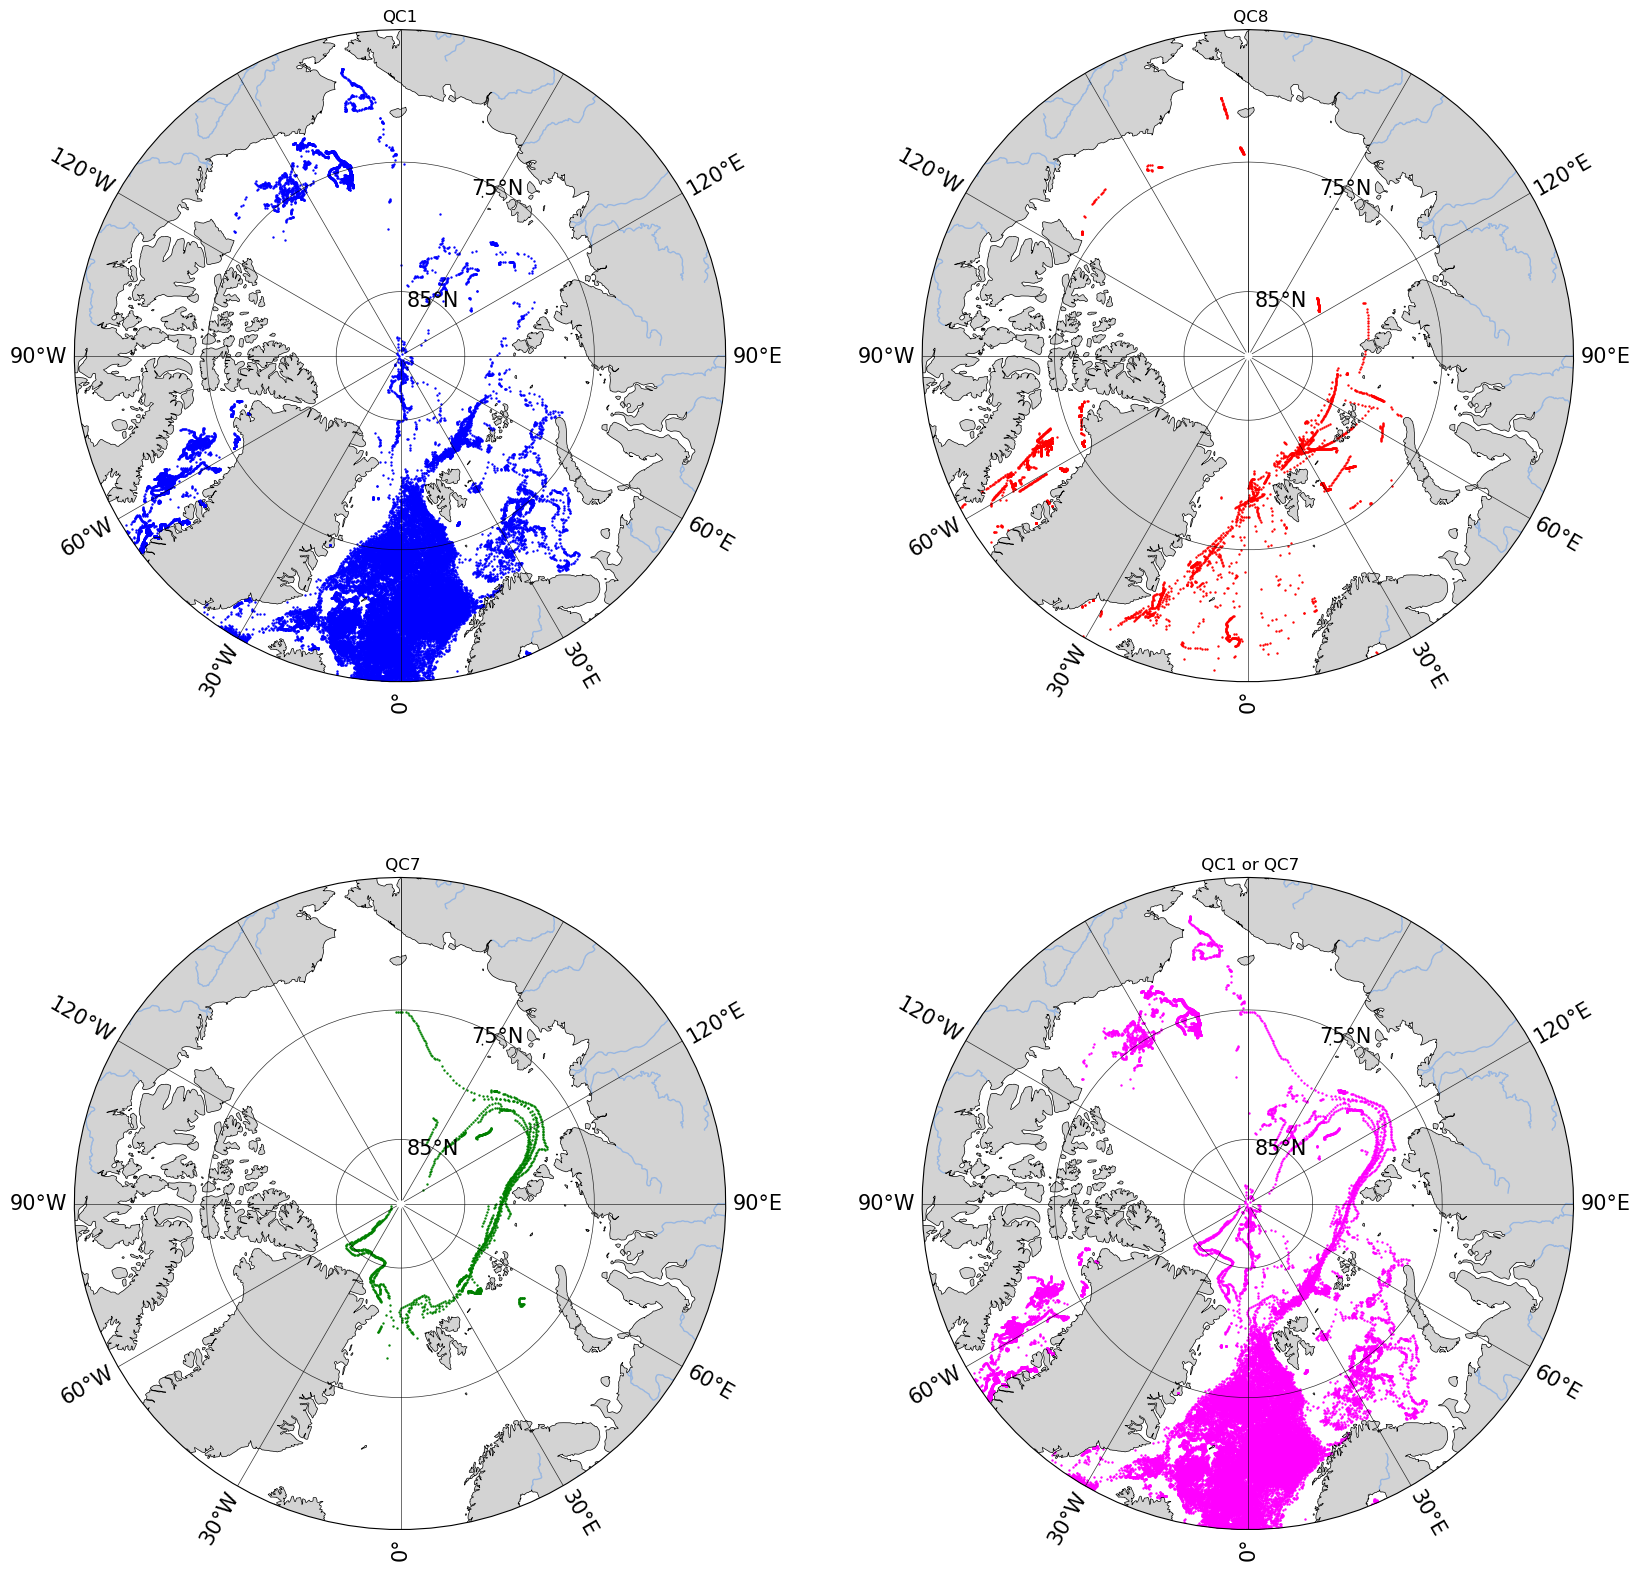

In [46]:
f,ax = plt.subplots(2,2,figsize=[15,15],subplot_kw={'projection': ccrs.NorthPolarStereo()})
ax=ax.ravel()
ftz=15


plt.subplots_adjust(top=1, bottom=0, left=0, right=1, hspace=0.3
                    ,
                    wspace=0.3)


Atools.plot_arctic_ax_map_new(ax[0])
ax[0].scatter(ds_final_qc1.prof_lon,ds_final_qc1.prof_lat,color='blue',marker='.',transform=ccrs.PlateCarree(),s=2)
ax[0].set_title('QC1')

Atools.plot_arctic_ax_map_new(ax[1])
ax[1].scatter(ds_final_qc8.prof_lon,ds_final_qc8.prof_lat,color='red',marker='.',transform=ccrs.PlateCarree(),s=2)
ax[1].set_title(' QC8')

Atools.plot_arctic_ax_map_new(ax[2])
ax[2].scatter(ds_final_qc7.prof_lon,ds_final_qc7.prof_lat,color='green',marker='.',transform=ccrs.PlateCarree(),s=2)
ax[2].set_title(' QC7')


Atools.plot_arctic_ax_map_new(ax[3])
ax[3].scatter(ds_final_qc1_qc7.prof_lon,ds_final_qc1_qc7.prof_lat,color='magenta',marker='.',transform=ccrs.PlateCarree(),s=2)
ax[3].set_title(' QC1 or QC7')
plt.savefig('plot_spatial_distribution.png')

In [92]:
ds_final_prof = ds_final.where(ds_final.prof_descr==b'ARGO7900177                   ',drop=True)

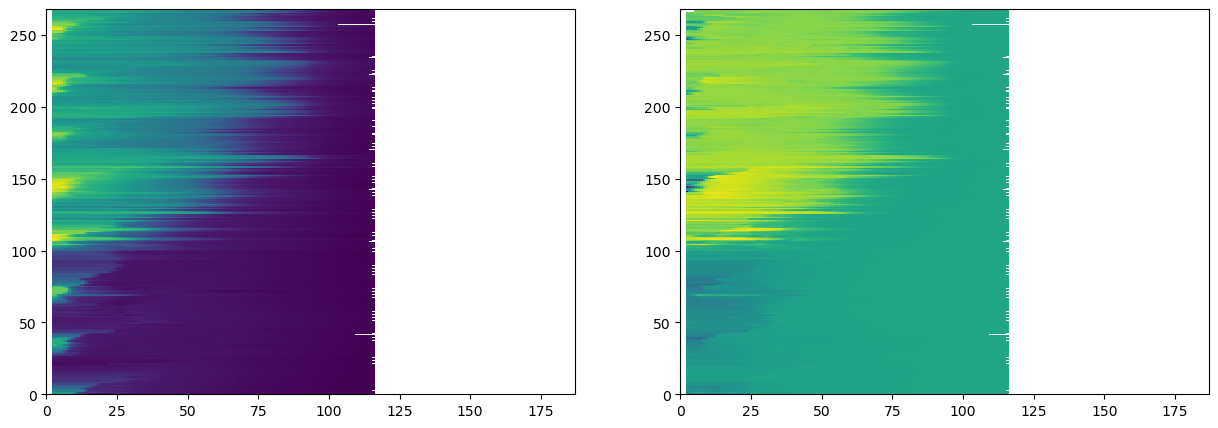

In [96]:
f,ax = plt.subplots(1,2, figsize=[15,5])

ax=ax.ravel()


ax[0].pcolor(ds_final_prof.prof_T)
ax[1].pcolor(ds_final_prof.prof_S)

In [91]:
ds_final.prof_descr.values

array([b'ARGO7900177                   ',
       b'ARGO7900177                   ',
       b'ARGO7900177                   ', ...,
       b'ARGO6900448                   ',
       b'ARGO6900448                   ',
       b'ARGO6900448                   '], dtype='|S30')

In [10]:
test = itp.copy()

In [11]:
test["SPEED"] = xr.where(mask, speed_corr)

TypeError: where() missing 1 required positional argument: 'y'